# LRJ Event Classifier Training

Binary classification: **signal** (HH→bbbb) vs **background** (QCD dijet).  
Features: jet substructure variables for leading + subleading LRJs.  
Missing values handled via median imputation + missingness-indicator columns.

In [91]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# ── papermill parameters ─────────────────────────────────────────────────
USE_ETA_PHI    = True          # include eta & phi in all inputs
N_MAX_JETS     = 10            # max cone jets per event (zero-padded)
N_EPOCHS       = 50            # training epochs
HIDDEN_DIMS    = [256, 128, 64]  # MLP hidden layer sizes
DROPOUT        = 0.3           # dropout rate
BATCH_SIZE     = 512           # training batch size
TARGET_RATE_HZ = 10e3          # working-point rate for ROC annotation (Hz)
USE_CONE_DELTA_R = True   # add deltaR between pairs of leading 4 cone jets
FIRMWARE_FRIENDLY  = False   # small no-BN architecture for FPGA deployment
FIRMWARE_HIDDEN    = [64, 32]  # hidden dims when FIRMWARE_FRIENDLY=True

In [ ]:
_dims_str = '-'.join(str(d) for d in HIDDEN_DIMS)
_eta_str  = 'etaphi' if USE_ETA_PHI else 'noetaphi'
_dr_str  = '_dR' if USE_CONE_DELTA_R else ''
_fw_str  = '_fw' if FIRMWARE_FRIENDLY else ''
PLOT_DIR = Path('outputs') / f'{_eta_str}{_dr_str}{_fw_str}_jets{N_MAX_JETS}_hidden{_dims_str}_epochs{N_EPOCHS}'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Saving plots to: {PLOT_DIR.resolve()}')

## 1. Load data

In [92]:
DATA_DIR = "../data"

sig = pd.read_parquet(f"{DATA_DIR}/HHbbbb_rMerge2_IOs_128_Seeds_2_R2_1.21_IO_gepCellsTowers_Seed_gepWTAConeCellsTowersJets_SK_v3.parquet")
bkg = pd.read_parquet(f"{DATA_DIR}/mc21_jj_JZ_SK.parquet")

print(f"Signal events:     {len(sig):>6}")
print(f"Background events: {len(bkg):>6}")

Signal events:      10000
Background events:  86225


In [93]:
sig.head()

,jetTaggerLeadingLRJEt,jetTaggerLeadingLRJEta,jetTaggerLeadingLRJPhi,jetTaggerLeadingLRJMassApprox,jetTaggerLeadingLRJTau_1,jetTaggerLeadingLRJTau_2,jetTaggerLeadingLRJTau_21,jetTaggerLeadingLRJPsi_R,jetTaggerLeadingLRJSubjetMultiplicity,jetTaggerSubleadingLRJEt,...,jetTaggerSubleadingLRJPsi_R,jetTaggerSubleadingLRJSubjetMultiplicity,coneJetSK_pT,coneJetSK_Eta,coneJetSK_Phi,coneJetSK_NConstituents,mcEventWeight,sumOfWeightsForSample,eventWeights,sampleJZSlice
0,73.125,1.0,-1.4,0.0,0.000000,0.000000,0.000000,0.713281,0,41.000,...,0.335156,0,"[24.49567413330078, 23.1200008392334, 22.95396...","[-0.44999998807907104, 1.75, 0.349999994039535...","[0.6381360292434692, -1.4235341548919678, -1.4...","[4, 6, 6, 5, 4, 4, 3, 2, 2, 1]",0.032254,0.080405,12331.891617,3
1,186.500,0.1,-1.4,0.0,0.218750,0.000000,0.000000,0.558594,1,135.625,...,0.498438,2,"[145.1859130859375, 95.59452819824219, 30.3351...","[0.15000000596046448, 0.3499999940395355, 0.94...","[-1.9144079685211182, 1.3253593444824219, 2.01...","[5, 14, 4, 6, 2]",0.032254,0.080405,12331.891617,3
2,221.500,-0.7,-2.2,130.0,0.386719,0.125000,0.323232,0.446875,2,135.125,...,0.403906,2,"[97.90011596679688, 86.68980407714844, 59.6257...","[-0.75, -0.550000011920929, -0.150000005960464...","[-1.8162332773208618, -2.5034565925598145, 0.9...","[6, 8, 7, 8, 5, 4]",0.032254,0.080405,12331.891617,3
3,91.250,0.0,-0.3,0.0,0.542969,0.000000,0.000000,0.910938,1,63.875,...,0.360938,1,"[72.17701721191406, 37.99336242675781, 14.2934...","[1.0499999523162842, 1.5499999523162842, -0.94...","[-0.3436116874217987, 2.4052817821502686, -0.2...","[7, 10, 4, 2, 2]",0.032254,0.080405,12331.891617,3
4,144.125,1.0,1.5,52.0,0.292969,0.148438,0.506667,0.317969,2,140.250,...,0.799219,2,"[104.03262329101562, 85.35072326660156, 45.451...","[0.15000000596046448, 1.149999976158142, 1.049...","[-1.2271846532821655, 1.718058466911316, 1.325...","[3, 10, 6, 7, 4, 4, 4]",0.032254,0.080405,12331.891617,3


In [94]:
bkg.head()

,jetTaggerLeadingLRJEt,jetTaggerLeadingLRJEta,jetTaggerLeadingLRJPhi,jetTaggerLeadingLRJMassApprox,jetTaggerLeadingLRJTau_1,jetTaggerLeadingLRJTau_2,jetTaggerLeadingLRJTau_21,jetTaggerLeadingLRJPsi_R,jetTaggerLeadingLRJSubjetMultiplicity,jetTaggerSubleadingLRJEt,...,jetTaggerSubleadingLRJPsi_R,jetTaggerSubleadingLRJSubjetMultiplicity,coneJetSK_pT,coneJetSK_Eta,coneJetSK_Phi,coneJetSK_NConstituents,mcEventWeight,sumOfWeightsForSample,eventWeights,sampleJZSlice
0,28.875,1.0,-0.2,0.0,0.0,0.0,0.0,0.541406,0,1.875,...,0.360938,0,[7.960000514984131],[1.0499999523162842],[-0.2454369217157364],[2],1.0,10000.0,575188.72011,0
1,0.000,-4.9,3.0,0.0,0.0,0.0,0.0,0.000000,0,0.000,...,0.000000,0,[],[],[],[],1.0,10000.0,575188.72011,0
2,2.250,-4.9,3.0,0.0,0.0,0.0,0.0,0.421094,0,2.250,...,0.421094,0,[],[],[],[],1.0,10000.0,575188.72011,0
3,24.000,1.5,0.0,0.0,0.0,0.0,0.0,0.498438,0,0.000,...,0.000000,0,[10.161192893981934],[1.4500000476837158],[-0.04908738657832146],[2],1.0,10000.0,575188.72011,0
4,37.875,0.9,1.8,0.0,0.0,0.0,0.0,0.481250,0,21.000,...,0.378125,0,"[16.51181411743164, 8.557056427001953]","[0.949999988079071, -1.0499999523162842]","[1.8162332773208618, 0.4417864680290222]","[5, 2]",1.0,10000.0,575188.72011,0


## 2. Feature selection, labels & sample weights

In [ ]:
import itertools

CONE_COLS = ['coneJetSK_pT', 'coneJetSK_Eta', 'coneJetSK_Phi', 'coneJetSK_NConstituents']
EXCLUDE   = ['mcEventWeight', 'sumOfWeightsForSample', 'eventWeights', 'sampleJZSlice']

if USE_ETA_PHI:
    SCALAR_FEATURES = [c for c in sig.columns if c not in EXCLUDE and c not in CONE_COLS]
    CONE_VARS       = ['pT', 'Eta', 'Phi', 'NConstituents']
else:
    ETA_PHI_COLS    = [c for c in sig.columns if 'Eta' in c or 'Phi' in c]
    SCALAR_FEATURES = [c for c in sig.columns
                       if c not in EXCLUDE and c not in CONE_COLS and c not in ETA_PHI_COLS]
    CONE_VARS       = ['pT', 'NConstituents']

CONE_FEATURES = [f'coneJet_{v}_jet{j}'
                 for j in range(N_MAX_JETS)
                 for v in CONE_VARS]

print(f'USE_ETA_PHI      : {USE_ETA_PHI}')
print(f'Scalar features  : {len(SCALAR_FEATURES)}')
print(f'Cone jet features: {len(CONE_FEATURES)}  ({N_MAX_JETS} jets x {len(CONE_VARS)} vars)')

# deltaR between pairs of the leading N_DELTA_R_JETS cone jets
N_DELTA_R_JETS = 4
_pairs = list(itertools.combinations(range(N_DELTA_R_JETS), 2))
DELTA_R_FEATURES = [f'coneJet_dR_j{i}j{j}' for i, j in _pairs] if USE_CONE_DELTA_R else []

FEATURES = SCALAR_FEATURES + CONE_FEATURES + DELTA_R_FEATURES
print(f'DeltaR features  : {len(DELTA_R_FEATURES)}  (pairs among leading {N_DELTA_R_JETS} jets)')
print(f'Total            : {len(FEATURES)}')

Scalar features : 18
Cone jet features: 40  (10 jets x 4 vars)
Total            : 58


In [ ]:


def delta_r(eta1, phi1, eta2, phi2):
    dphi = phi1 - phi2
    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi   # wrap to [-pi, pi]
    return np.sqrt((eta1 - eta2)**2 + dphi**2)


def expand_cone_jets(df: pd.DataFrame, n_max: int = N_MAX_JETS) -> np.ndarray:
    """Variable-length coneJetSK arrays → fixed (n_events, n_max*len(CONE_VARS)) matrix.
    Jets sorted by pT descending; absent slots are zero (firmware default)."""
    n_ev   = len(df)
    n_vars = len(CONE_VARS)
    out    = np.zeros((n_ev, n_max * n_vars), dtype=float)
    pt_arr  = df['coneJetSK_pT'].to_numpy()
    eta_arr = df['coneJetSK_Eta'].to_numpy()
    phi_arr = df['coneJetSK_Phi'].to_numpy()
    nc_arr  = df['coneJetSK_NConstituents'].to_numpy()
    for i in range(n_ev):
        pts = np.asarray(pt_arr[i], dtype=float)
        n   = min(len(pts), n_max)
        if n == 0:
            continue
        order = np.argsort(pts)[::-1][:n]
        vals_by_var = [pts[order]]
        if 'Eta' in CONE_VARS: vals_by_var.append(np.asarray(eta_arr[i], dtype=float)[order])
        if 'Phi' in CONE_VARS: vals_by_var.append(np.asarray(phi_arr[i], dtype=float)[order])
        vals_by_var.append(np.asarray(nc_arr[i], dtype=float)[order])
        for j in range(n):
            for k, v in enumerate(vals_by_var):
                out[i, j*n_vars+k] = v[j]
    return out


def compute_delta_r(df: pd.DataFrame) -> np.ndarray:
    """DeltaR between all pairs of the leading N_DELTA_R_JETS cone jets.
    Returns zeros for pairs where one or both jets are absent."""
    pairs  = list(itertools.combinations(range(N_DELTA_R_JETS), 2))
    n_ev   = len(df)
    out    = np.zeros((n_ev, len(pairs)), dtype=float)
    pt_arr  = df['coneJetSK_pT'].to_numpy()
    eta_arr = df['coneJetSK_Eta'].to_numpy()
    phi_arr = df['coneJetSK_Phi'].to_numpy()
    for i in range(n_ev):
        pts  = np.asarray(pt_arr[i], dtype=float)
        n    = len(pts)
        if n < 2:
            continue
        order = np.argsort(pts)[::-1]
        etas  = np.asarray(eta_arr[i], dtype=float)[order]
        phis  = np.asarray(phi_arr[i], dtype=float)[order]
        for col, (a, b) in enumerate(pairs):
            if a < n and b < n:
                out[i, col] = delta_r(etas[a], phis[a], etas[b], phis[b])
    return out


def build_features(df: pd.DataFrame, source_df: pd.DataFrame) -> np.ndarray:
    scalars = df[SCALAR_FEATURES].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=float)
    cones   = expand_cone_jets(source_df)
    parts   = [scalars, cones]
    if USE_CONE_DELTA_R:
        parts.append(compute_delta_r(source_df))
    return np.concatenate(parts, axis=1)


sig_X = build_features(sig, sig)
bkg_X = build_features(bkg, bkg)

sig_w = np.ones(len(sig))
bkg_w = np.abs(bkg['eventWeights'].values.astype(float))
bkg_w = bkg_w / bkg_w.mean()

X = np.concatenate([sig_X, bkg_X], axis=0)
y = np.concatenate([np.ones(len(sig)), np.zeros(len(bkg))])
w = np.concatenate([sig_w, bkg_w])

rng  = np.random.default_rng(42)
perm = rng.permutation(len(y))
X, y, w = X[perm], y[perm], w[perm]

print(f'X shape : {X.shape}')
print(f'Signal  : {int(y.sum())}  Background: {int((1-y).sum())}')

X shape : (96225, 58)
Signal  : 10000  Background: 86225
NaN count in scalar features   : 0
NaN count in cone jet features : 0


## 3. Train / validation split

In [97]:
X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
    X, y, w, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(y_tr)}  |  Val: {len(y_val)}")

Train: 76980  |  Val: 19245


## 4. Missing-value handling

For each feature that has **any** NaN in the training set we append a binary indicator column (1 = value was missing). The network can then learn separately from the observed value and from the fact that it was absent.

In [98]:
# Impute with 0 — matches firmware behaviour (missing inputs arrive as zero).
# keep_empty_features=True ensures all-NaN columns (e.g. coneJetSK_*) are
# preserved and filled with 0 rather than silently dropped.
imputer   = SimpleImputer(strategy='constant', fill_value=0.0,
                          keep_empty_features=True)
X_tr_imp  = imputer.fit_transform(X_tr)
X_val_imp = imputer.transform(X_val)

X_tr_full  = X_tr_imp
X_val_full = X_val_imp

print(f"Feature matrix shape  →  train: {X_tr_full.shape}  val: {X_val_full.shape}")
assert X_tr_full.shape[1] == len(FEATURES), 'column count mismatch!'

Feature matrix shape  →  train: (76980, 58)  val: (19245, 58)


## 5. Standardisation

StandardScaler (mean=0, variance=1) fitted on training data only.  
The binary indicator columns are left unchanged (they're already in {0,1}).

In [99]:
scaler = StandardScaler()
X_tr_full  = scaler.fit_transform(X_tr_full)
X_val_full = scaler.transform(X_val_full)

print(f"Train  — mean: {X_tr_full.mean():.4f}  std: {X_tr_full.std():.4f}")
print(f"Val    — mean: {X_val_full.mean():.4f}  std: {X_val_full.std():.4f}")

Train  — mean: 0.0000  std: 1.0000
Val    — mean: -0.0004  std: 0.9962


## 6. Device

In [100]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM: 17.1 GB


## 7. PyTorch Dataset & DataLoader

In [101]:
class JetDataset(Dataset):
    def __init__(self, X, y, w):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.w = torch.tensor(w, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.w[idx]


train_loader = DataLoader(
    JetDataset(X_tr_full, y_tr, w_tr),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=(device.type == 'cuda'),
)
val_loader = DataLoader(
    JetDataset(X_val_full, y_val, w_val),
    batch_size=BATCH_SIZE * 4, shuffle=False,
    num_workers=4, pin_memory=(device.type == 'cuda'),
)
n_in = X_tr_full.shape[1]
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")
print(f"Input features: {n_in}")

Train batches: 151  |  Val batches: 10


## 8. Model

In [102]:
class EventClassifier(nn.Module):
    """MLP classifier. BatchNorm and Dropout are omitted in firmware mode
    to minimise resource usage and simplify HLS4ML export."""

    def __init__(self, n_in: int, hidden: list[int] = [256, 128, 64],
                 dropout: float = 0.3, firmware: bool = False):
        super().__init__()
        layers = []
        dim = n_in
        for h in hidden:
            layers.append(nn.Linear(dim, h))
            if not firmware:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if not firmware:
                layers.append(nn.Dropout(dropout))
            dim = h
        layers.append(nn.Linear(dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


_hidden = FIRMWARE_HIDDEN if FIRMWARE_FRIENDLY else HIDDEN_DIMS
model   = EventClassifier(
    n_in,
    hidden=_hidden,
    dropout=DROPOUT,
    firmware=FIRMWARE_FRIENDLY,
).to(device)

print(f'Firmware-friendly: {FIRMWARE_FRIENDLY}')
print(f'Architecture     : {n_in} → {" → ".join(str(h) for h in _hidden)} → 1')
print(model)
print(f'\nParameters: {sum(p.numel() for p in model.parameters()):,}')

EventClassifier(
  (net): Sequential(
    (0): Linear(in_features=58, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Parameters: 57,217


## 8a. Model diagram

`torchinfo` gives a Keras-style layer table.  
`torchviz` renders the computation graph (requires `sudo apt-get install -y graphviz` first).

In [103]:
from torchinfo import summary

summary(
    model,
    input_size=(BATCH_SIZE, n_in),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    row_settings=['var_names'],
    device=device,
)

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
EventClassifier (EventClassifier)        [512, 58]                 [512]                     --                        True
├─Sequential (net)                       [512, 58]                 [512, 1]                  --                        True
│    └─Linear (0)                        [512, 58]                 [512, 256]                15,104                    True
│    └─BatchNorm1d (1)                   [512, 256]                [512, 256]                512                       True
│    └─ReLU (2)                          [512, 256]                [512, 256]                --                        --
│    └─Dropout (3)                       [512, 256]                [512, 256]                --                        --
│    └─Linear (4)                        [512, 256]                [512, 128]                32,896                    True
│    └─

## 9. Training

In [105]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)


def run_epoch(loader: DataLoader, train: bool) -> float:
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for X_b, y_b, w_b in loader:
            X_b = X_b.to(device, non_blocking=True)
            y_b = y_b.to(device, non_blocking=True)
            w_b = w_b.to(device, non_blocking=True)

            logits = model(X_b)
            # BCEWithLogitsLoss per-sample weighting
            loss = F.binary_cross_entropy_with_logits(logits, y_b, weight=w_b)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(y_b)
    return total_loss / len(loader.dataset)


train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):
    tl = run_epoch(train_loader, train=True)
    vl = run_epoch(val_loader,   train=False)
    scheduler.step(vl)
    train_losses.append(tl)
    val_losses.append(vl)
    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d}/{N_EPOCHS}  train={tl:.4f}  val={vl:.4f}  "
              f"lr={optimizer.param_groups[0]['lr']:.2e}")

Epoch   5/50  train=0.0613  val=0.0597  lr=1.00e-03
Epoch  10/50  train=0.0580  val=0.0578  lr=1.00e-03
Epoch  15/50  train=0.0549  val=0.0566  lr=1.00e-03
Epoch  20/50  train=0.0536  val=0.0584  lr=1.00e-03
Epoch  25/50  train=0.0526  val=0.0576  lr=5.00e-04
Epoch  30/50  train=0.0506  val=0.0572  lr=2.50e-04
Epoch  35/50  train=0.0483  val=0.0576  lr=2.50e-04
Epoch  40/50  train=0.0467  val=0.0578  lr=1.25e-04
Epoch  45/50  train=0.0464  val=0.0576  lr=6.25e-05
Epoch  50/50  train=0.0465  val=0.0579  lr=3.13e-05


## 10. Training curves

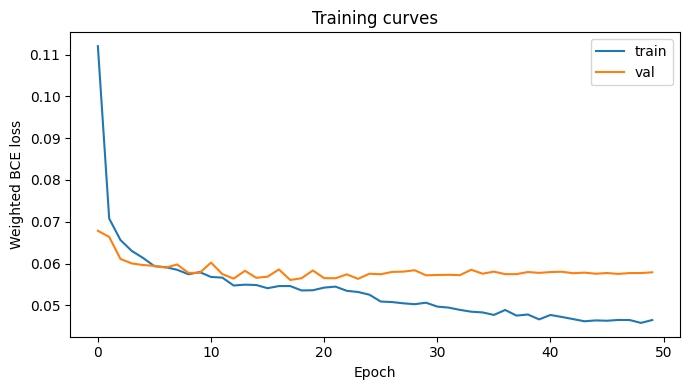

In [106]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label='train')
ax.plot(val_losses,   label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted BCE loss')
ax.set_title('Training curves')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'training_curves.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 11. ROC curve (weighted)

Signal efficiency (TPR) vs background rate (FPR), both computed with `eventWeights`.  
Also shown as the HEP-style background rejection (1 / FPR) vs signal efficiency.

Total background rate (sum of eventWeights): 65.27 MHz

At 10 kHz working point:
  Background rate   : 10.10 kHz
  Signal efficiency : 0.3920
  NN score threshold: 0.9889


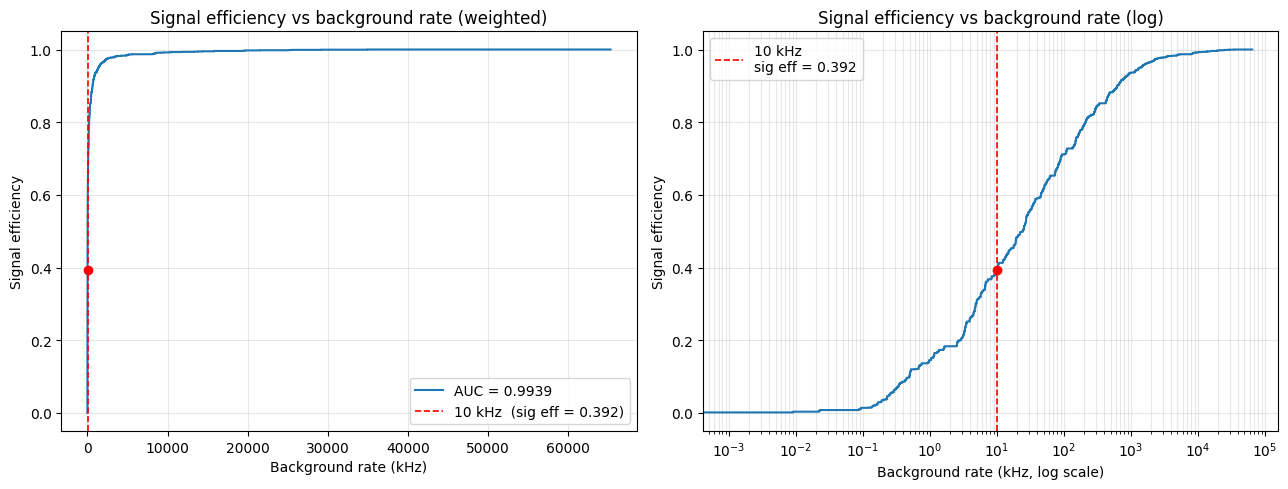

In [107]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# ── absolute background rate from the full dataset ────────────────────────
# Summing eventWeights over all JZ slices gives the physical ~40 MHz rate.
total_bkg_rate_hz = bkg['eventWeights'].sum()
print(f"Total background rate (sum of eventWeights): {total_bkg_rate_hz/1e6:.2f} MHz")


# ── inference on validation set ──────────────────────────────────────────
model.eval()
all_logits, all_y, all_w = [], [], []

with torch.no_grad():
    for X_b, y_b, w_b in val_loader:
        logits = model(X_b.to(device))
        all_logits.append(logits.cpu())
        all_y.append(y_b)
        all_w.append(w_b)

scores = torch.sigmoid(torch.cat(all_logits)).numpy()
y_true = torch.cat(all_y).numpy()
weights = torch.cat(all_w).numpy()

# ── weighted ROC ─────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_true, scores, sample_weight=weights)
roc_auc = auc(fpr, tpr)

# fpr is already the weighted fraction; convert to absolute rate
rate_hz = fpr * total_bkg_rate_hz

# ── working point at TARGET_RATE_HZ ──────────────────────────────────────
idx_wp = np.searchsorted(rate_hz, TARGET_RATE_HZ)
sig_eff_at_wp  = tpr[idx_wp]
rate_at_wp     = rate_hz[idx_wp]
thresh_at_wp   = thresholds[idx_wp]
print(f"\nAt {TARGET_RATE_HZ/1e3:.0f} kHz working point:")
print(f"  Background rate   : {rate_at_wp/1e3:.2f} kHz")
print(f"  Signal efficiency : {sig_eff_at_wp:.4f}")
print(f"  NN score threshold: {thresh_at_wp:.4f}")

# ── plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: linear background rate
axes[0].plot(rate_hz / 1e3, tpr, label=f'AUC = {roc_auc:.4f}')
axes[0].axvline(TARGET_RATE_HZ / 1e3, color='red', ls='--', lw=1.2,
                label=f'{TARGET_RATE_HZ/1e3:.0f} kHz  (sig eff = {sig_eff_at_wp:.3f})')
axes[0].scatter([rate_at_wp / 1e3], [sig_eff_at_wp], color='red', zorder=5)
axes[0].set_xlabel('Background rate (kHz)')
axes[0].set_ylabel('Signal efficiency')
axes[0].set_title('Signal efficiency vs background rate (weighted)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: log background rate — resolves the low-rate region
axes[1].plot(rate_hz / 1e3, tpr)
axes[1].axvline(TARGET_RATE_HZ / 1e3, color='red', ls='--', lw=1.2,
                label=f'{TARGET_RATE_HZ/1e3:.0f} kHz\nsig eff = {sig_eff_at_wp:.3f}')
axes[1].scatter([rate_at_wp / 1e3], [sig_eff_at_wp], color='red', zorder=5)
axes[1].set_xscale('log')
axes[1].set_xlabel('Background rate (kHz, log scale)')
axes[1].set_ylabel('Signal efficiency')
axes[1].set_title('Signal efficiency vs background rate (log)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'roc_curve.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [108]:
# ── rate at 20% signal efficiency ────────────────────────────────────────
TARGET_SIG_EFF = 0.20

# tpr is monotonically increasing; find first point >= target
idx_20 = np.searchsorted(tpr, TARGET_SIG_EFF)
rate_at_20   = rate_hz[idx_20]
thresh_at_20 = thresholds[idx_20]

print(f"At {TARGET_SIG_EFF:.0%} signal efficiency:")
print(f"  Background rate   : {rate_at_20/1e3:.2f} kHz  ({rate_at_20/1e6:.4f} MHz)")
print(f"  NN score threshold: {thresh_at_20:.4f}")

At 20% signal efficiency:
  Background rate   : 2.90 kHz  (0.0029 MHz)
  NN score threshold: 0.9967


## 12. Feature importance (permutation)

Each feature is shuffled in turn on the validation set; the drop in weighted AUC measures how much that feature contributes to discrimination.

Baseline weighted AUC: 0.9939


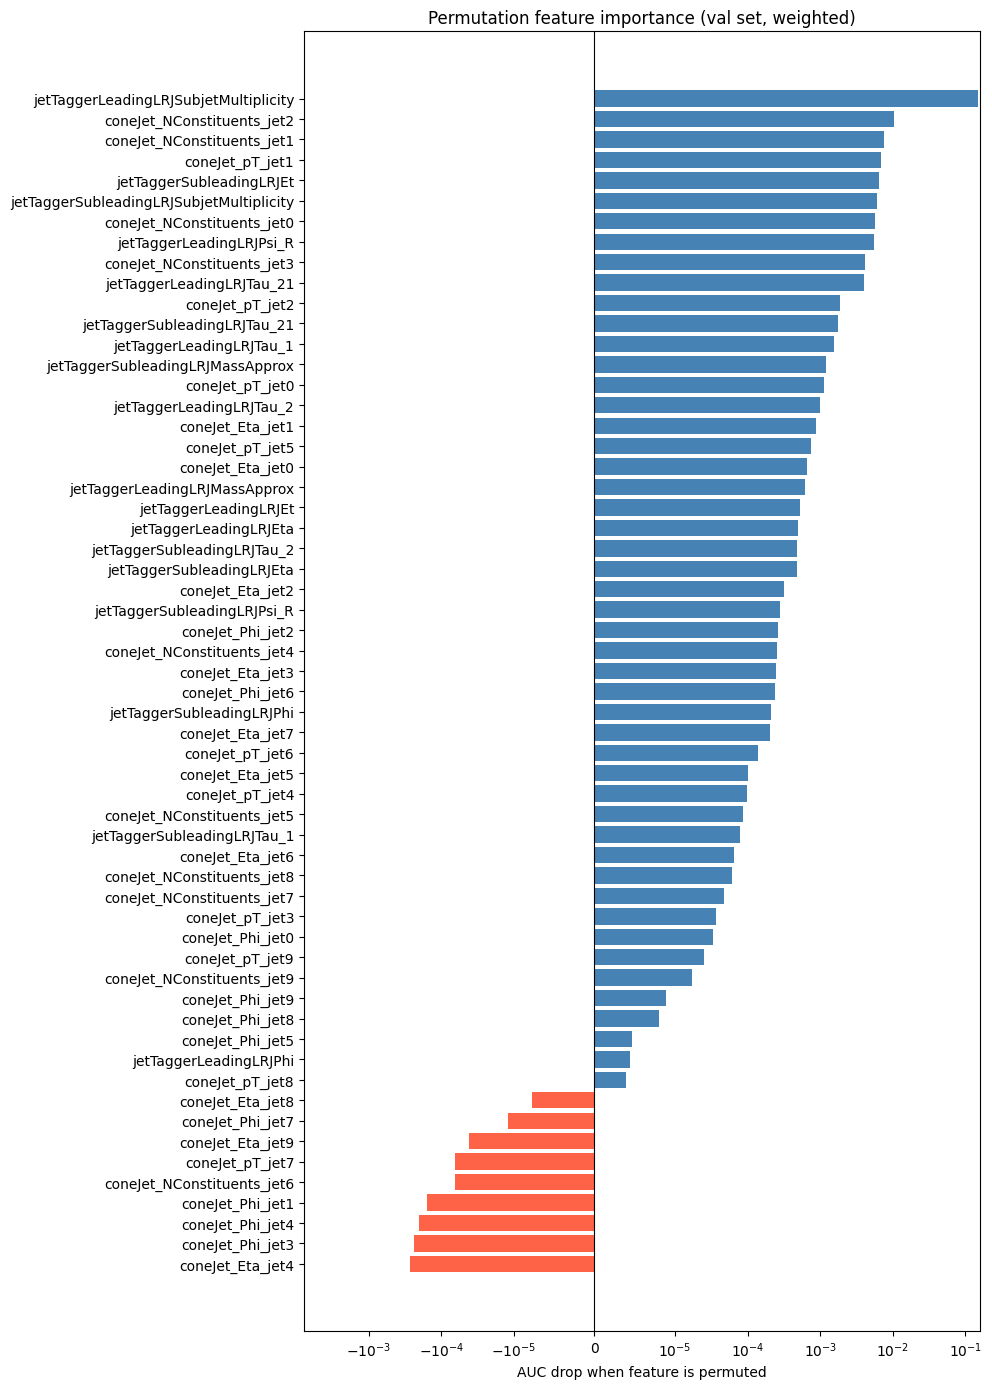


Ranked features:
  jetTaggerLeadingLRJSubjetMultiplicity          ΔAUC = +0.14957
  coneJet_NConstituents_jet2                     ΔAUC = +0.01020
  coneJet_NConstituents_jet1                     ΔAUC = +0.00765
  coneJet_pT_jet1                                ΔAUC = +0.00692
  jetTaggerSubleadingLRJEt                       ΔAUC = +0.00639
  jetTaggerSubleadingLRJSubjetMultiplicity       ΔAUC = +0.00603
  coneJet_NConstituents_jet0                     ΔAUC = +0.00574
  jetTaggerLeadingLRJPsi_R                       ΔAUC = +0.00549
  coneJet_NConstituents_jet3                     ΔAUC = +0.00413
  jetTaggerLeadingLRJTau_21                      ΔAUC = +0.00397
  coneJet_pT_jet2                                ΔAUC = +0.00185
  jetTaggerSubleadingLRJTau_21                   ΔAUC = +0.00173
  jetTaggerLeadingLRJTau_1                       ΔAUC = +0.00153
  jetTaggerSubleadingLRJMassApprox               ΔAUC = +0.00119
  coneJet_pT_jet0                                ΔAUC = +0.00114
  jetTa

In [109]:
from sklearn.metrics import roc_auc_score

def weighted_auc(X_scaled: np.ndarray) -> float:
    """Run inference and return weighted AUC."""
    model.eval()
    ds = JetDataset(X_scaled, y_val, w_val)
    dl = DataLoader(ds, batch_size=1024, shuffle=False)
    logits_list = []
    with torch.no_grad():
        for X_b, _, _ in dl:
            logits_list.append(model(X_b.to(device)).cpu())
    sc = torch.sigmoid(torch.cat(logits_list)).numpy()
    return roc_auc_score(y_val, sc, sample_weight=w_val)

# baseline AUC on unperturbed val set
X_val_perm = X_val_full.copy()   # scaled, with missing indicators
baseline_auc = weighted_auc(X_val_perm)
print(f"Baseline weighted AUC: {baseline_auc:.4f}")

# permute each continuous feature (leave indicator columns untouched)
rng = np.random.default_rng(42)
importances = {}
for i, feat in enumerate(FEATURES):
    orig = X_val_perm[:, i].copy()
    X_val_perm[:, i] = rng.permutation(orig)
    drop = baseline_auc - weighted_auc(X_val_perm)
    importances[feat] = drop
    X_val_perm[:, i] = orig   # restore

# sort and plot
feat_names = list(importances.keys())
imp_vals   = np.array([importances[f] for f in feat_names])
order      = np.argsort(imp_vals)[::-1]

fig, ax = plt.subplots(figsize=(10, 14))
colors = ['steelblue' if v >= 0 else 'tomato' for v in imp_vals[order]]
ax.barh(range(len(order)), imp_vals[order], color=colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([feat_names[i] for i in order], fontsize=10)
ax.axvline(0, color='k', lw=0.8)
# log scale on positive side only — shift to abs value with sign indicated by colour
ax.set_xscale('symlog', linthresh=1e-5)
ax.set_xlabel('AUC drop when feature is permuted')
ax.set_title('Permutation feature importance (val set, weighted)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'feature_importance.pdf', dpi=150, bbox_inches='tight')
plt.show()

print("\nRanked features:")
for i in order:
    print(f"  {feat_names[i]:<45s}  ΔAUC = {imp_vals[i]:+.5f}")

## 13. Feature distributions: accepted vs rejected at 10 kHz

Events with NN score ≥ `thresh_at_wp` are **accepted**; the rest are **rejected**.  
Histograms use pre-scaling (imputed) values so axes are physically interpretable.  
Background histograms are filled with `eventWeights`.

## 13a. Pre-cut feature distributions (signal vs background)

All validation events before any NN selection.  
Background filled with `eventWeights` so the shapes reflect the physical rate.  
Each histogram is normalised to unity (bin counts sum to 1) for shape comparison.

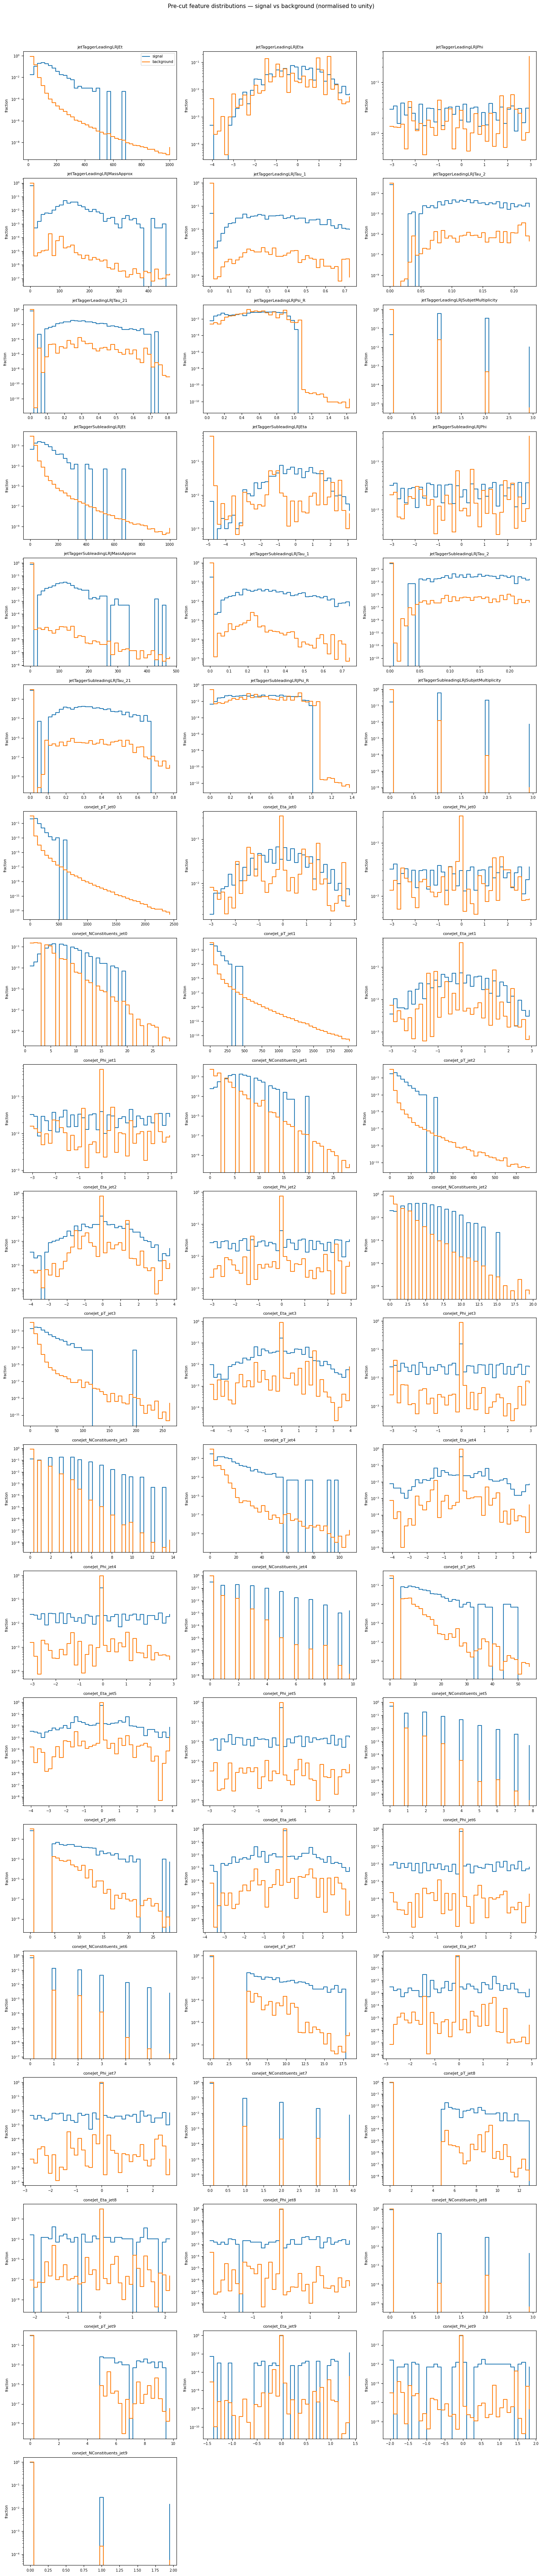

In [ ]:
# scores already computed in ROC cell
accepted = scores >= thresh_at_wp
is_sig = y_true == 1
is_bkg = y_true == 0

# With constant imputation all features are preserved
def norm_hist(vals, bins, weights=None):
    """Histogram normalised so bin counts sum to 1."""
    counts, edges = np.histogram(vals, bins=bins, weights=weights)
    total = counts.sum()
    return (counts / total if total > 0 else counts), edges

n_cols = 3
n_rows = int(np.ceil(len(FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()



for ax, (i, feat) in zip(axes, enumerate(FEATURES)):
    vals   = X_val_imp[:, i]
    finite = np.isfinite(vals)
    lo, hi = np.nanpercentile(vals[finite], [1, 99])
    bins   = np.linspace(lo, hi, 40)

    # signal (unweighted)
    c_sig, e = norm_hist(vals[is_sig & finite], bins)
    ax.step(e[:-1], c_sig, where='post', color='tab:blue',   lw=1.5, label='signal')

    # background weighted by eventWeights
    c_bkg, _ = norm_hist(vals[is_bkg & finite], bins, weights=w_val[is_bkg & finite])
    ax.step(e[:-1], c_bkg, where='post', color='tab:orange', lw=1.5, label='background')

    ax.set_title(feat, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_ylabel('fraction', fontsize=7)
    ax.set_yscale('log')

axes[0].legend(fontsize=7)
for ax in axes[len(FEATURES):]:
    ax.set_visible(False)

fig.suptitle('Pre-cut feature distributions — signal vs background (normalised to unity)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'precut_distributions.pdf', dpi=150, bbox_inches='tight')
plt.show()

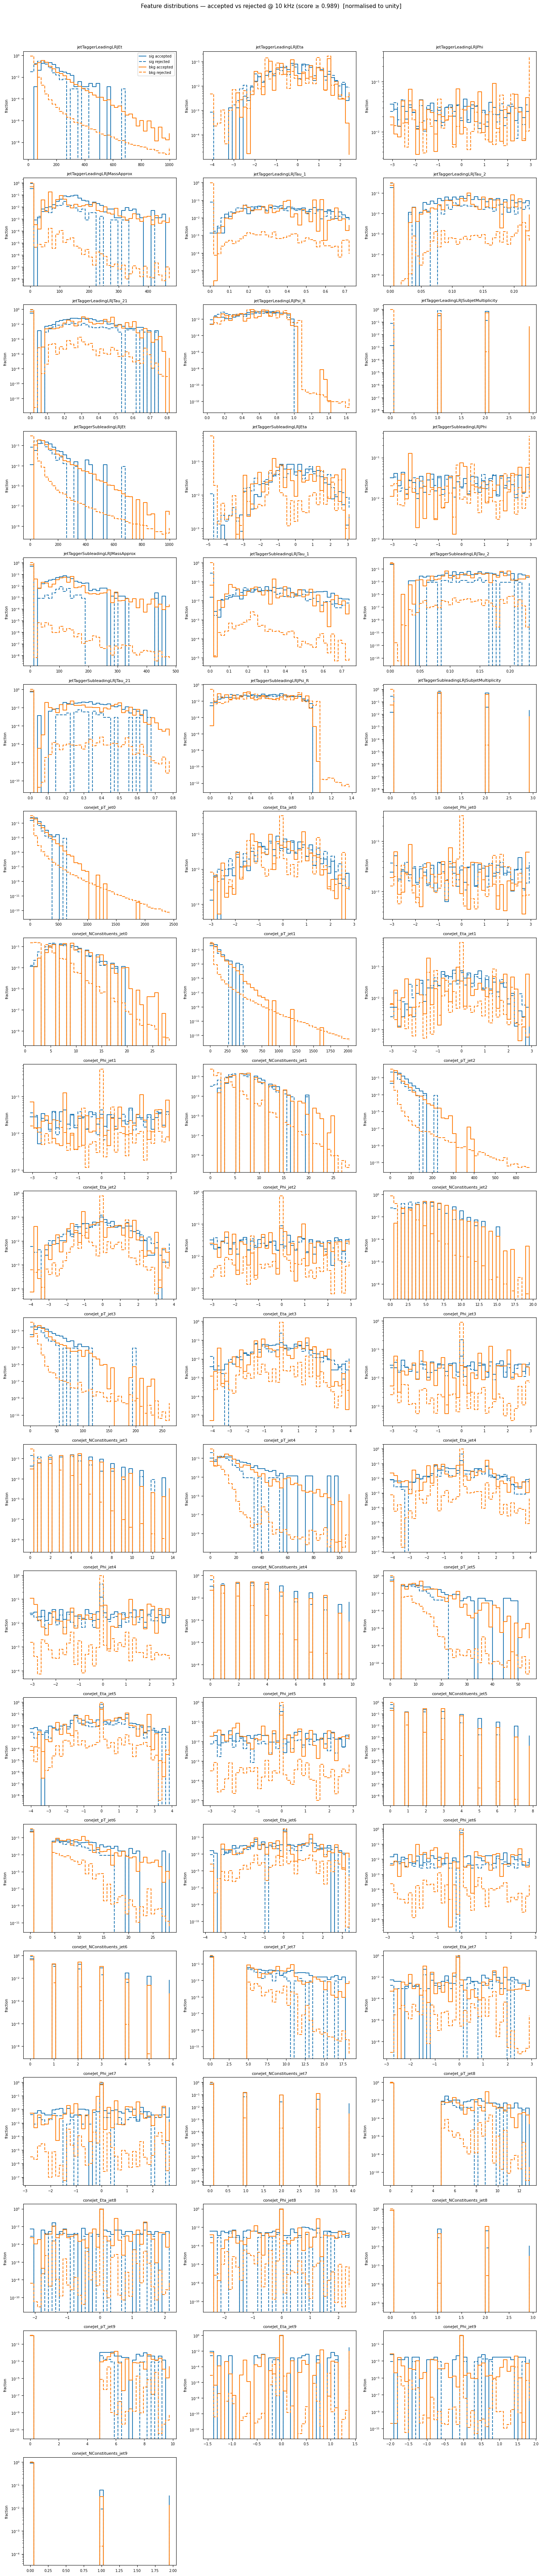

In [111]:
# scores already computed in ROC cell
accepted = scores >= thresh_at_wp
is_sig = y_true == 1
is_bkg = y_true == 0

# With constant imputation all features are preserved
def norm_hist(vals, bins, weights=None):
    """Histogram normalised so bin counts sum to 1."""
    counts, edges = np.histogram(vals, bins=bins, weights=weights)
    total = counts.sum()
    return (counts / total if total > 0 else counts), edges

n_cols = 3
n_rows = int(np.ceil(len(FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, (i, feat) in zip(axes, enumerate(FEATURES)):
    vals   = X_val_imp[:, i]
    finite = np.isfinite(vals)
    lo, hi = np.nanpercentile(vals[finite], [1, 99])
    bins   = np.linspace(lo, hi, 40)
    w      = np.diff(bins)[0]  # for step plots

    def plot_norm(mask, color, ls, label, use_weights=None):
        m = mask & finite
        ww = use_weights[m] if use_weights is not None else None
        c, e = norm_hist(vals[m], bins, weights=ww)
        ax.step(e[:-1], c, where='post', color=color, ls=ls, lw=1.5, label=label)

    plot_norm(is_sig & accepted,  'tab:blue',   '-',  'sig accepted')
    plot_norm(is_sig & ~accepted, 'tab:blue',   '--', 'sig rejected')
    plot_norm(is_bkg & accepted,  'tab:orange', '-',  'bkg accepted',  w_val)
    plot_norm(is_bkg & ~accepted, 'tab:orange', '--', 'bkg rejected',  w_val)

    ax.set_title(feat, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_ylabel('fraction', fontsize=7)
    ax.set_yscale('log')

axes[0].legend(fontsize=7)
for ax in axes[len(FEATURES):]:
    ax.set_visible(False)

fig.suptitle(f'Feature distributions — accepted vs rejected @ {TARGET_RATE_HZ/1e3:.0f} kHz '
             f'(score ≥ {thresh_at_wp:.3f})  [normalised to unity]',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'accepted_rejected_distributions.pdf', dpi=150, bbox_inches='tight')
plt.show()